<a href="https://colab.research.google.com/github/erikachaichuk/time_series_-_forecasting/blob/main/vix-returns-regime-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.sandwich_covariance import cov_hac
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import breaks_cusumolsresid

In [3]:
sp500 = pd.read_excel("Data Time Series.xlsx", sheet_name="SPX")
vix = pd.read_excel("Data Time Series.xlsx", sheet_name="VIX")

In [4]:
sp500["Date"] = pd.to_datetime(sp500["Date"])
vix["Date"] = pd.to_datetime(vix["Date"])

In [5]:
data = pd.merge(sp500, vix, on="Date", how="inner")

In [6]:
data = data.sort_values("Date").reset_index(drop=True)

In [7]:
data.head()

,Date,Last Price_x,Last Price_y
0,2024-01-03,4704.81,14.04
1,2024-01-04,4688.68,14.13
2,2024-01-05,4697.24,13.35
3,2024-01-08,4763.54,13.08
4,2024-01-09,4756.50,12.76


In [8]:
data.columns = ["date","sp500","vix"]

In [9]:
data["sp500_diff"] = data["sp500"].diff()
data["vix_diff"] = data["vix"].diff()

In [10]:
# Log returns (later used)
data["sp500_ret"] = np.log(data["sp500"]).diff()

# Additional variables
data["log_vix"] = np.log(data["vix"])
data["log_vix_diff"] = data["log_vix"].diff()

data.head()

,date,sp500,vix,sp500_diff,vix_diff,sp500_ret,log_vix,log_vix_diff
0,2024-01-03,4704.81,14.04,NaN,NaN,NaN,2.641910,NaN
1,2024-01-04,4688.68,14.13,-16.13,0.09,-0.003434,2.648300,0.006390
2,2024-01-05,4697.24,13.35,8.56,-0.78,0.001824,2.591516,-0.056784
3,2024-01-08,4763.54,13.08,66.30,-0.27,0.014016,2.571084,-0.020432
4,2024-01-09,4756.50,12.76,-7.04,-0.32,-0.001479,2.546315,-0.024769


In [11]:
data.isna().sum()

,0
date,0
sp500,0
vix,0
sp500_diff,1
vix_diff,1
sp500_ret,1
log_vix,0
log_vix_diff,1


In [12]:
data[data.isna().any(axis=1)]

,date,sp500,vix,sp500_diff,vix_diff,sp500_ret,log_vix,log_vix_diff
0,2024-01-03,4704.81,14.04,NaN,NaN,NaN,2.64191,NaN


### Covariance stationarity

In [13]:
data = data.set_index("date")

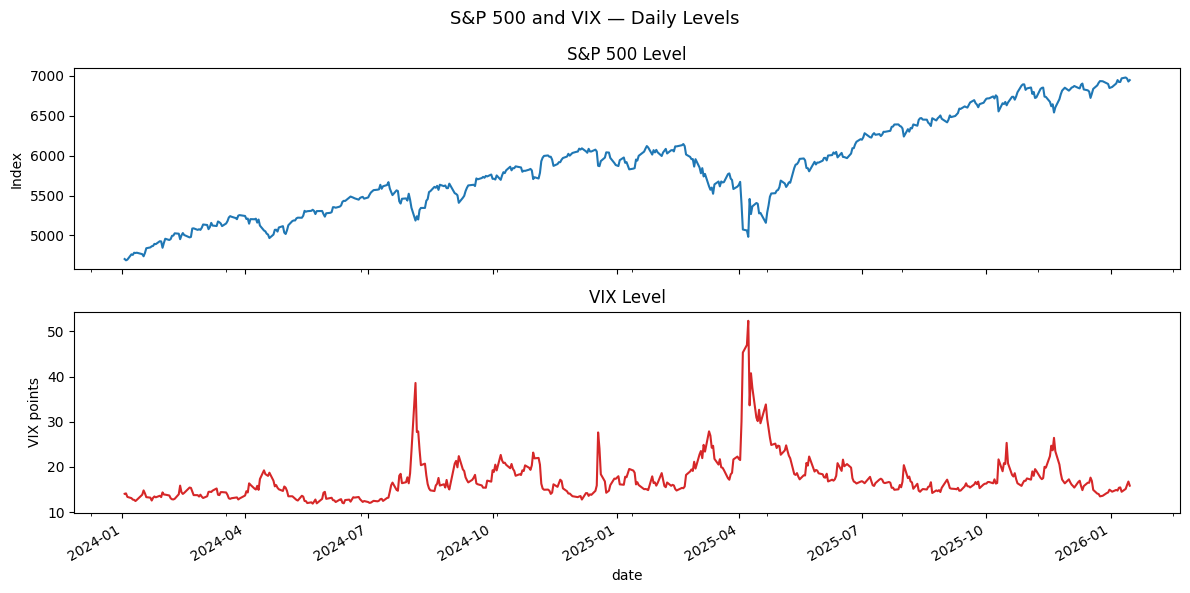

In [14]:
# Level plots
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("S&P 500 and VIX — Daily Levels", fontsize=13)

data["sp500"].plot(ax=axes[0], color="#1f77b4")
axes[0].set_title("S&P 500 Level")
axes[0].set_ylabel("Index")

data["vix"].plot(ax=axes[1], color="#d62728")
axes[1].set_title("VIX Level")
axes[1].set_ylabel("VIX points")

plt.tight_layout()
plt.savefig("fig1_levels.png", dpi=150, bbox_inches="tight")
plt.show()

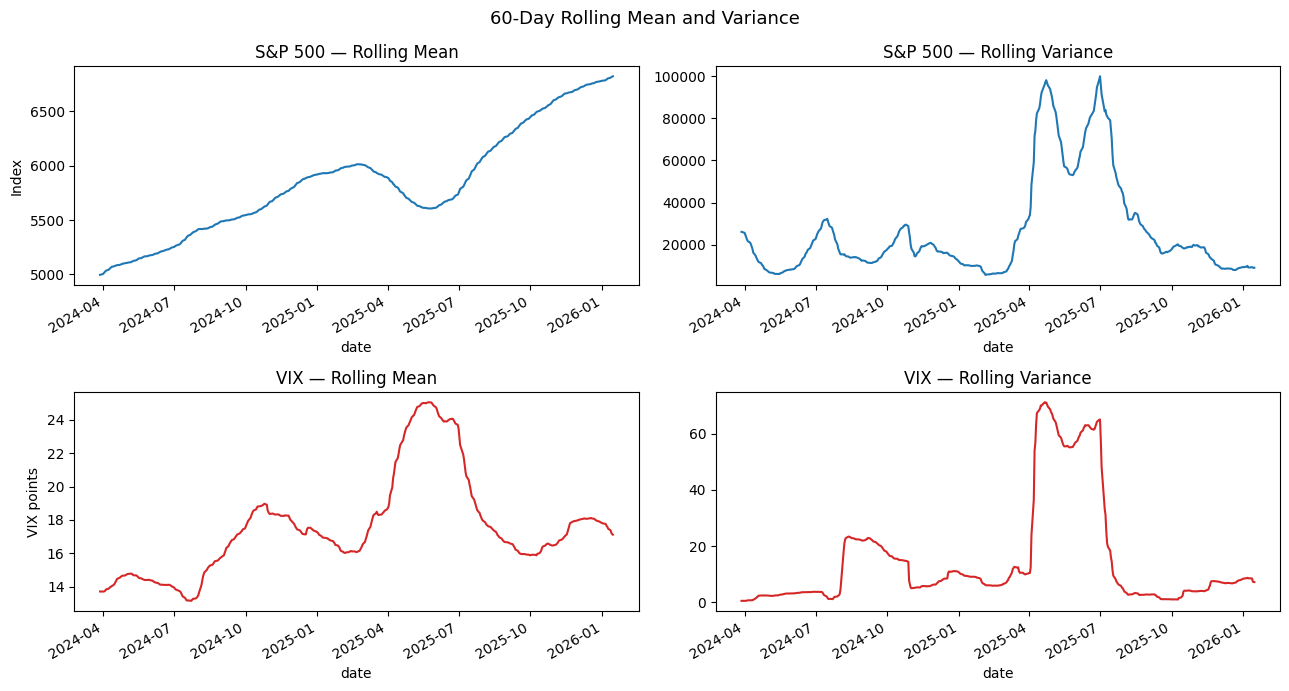

In [15]:
# Rolling means and variance
window = 60

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle(f"{window}-Day Rolling Mean and Variance", fontsize=13)

data["sp500"].rolling(window).mean().plot(ax=axes[0,0], color="#1f77b4")
axes[0,0].set_title("S&P 500 — Rolling Mean")
axes[0,0].set_ylabel("Index")

data["sp500"].rolling(window).var().plot(ax=axes[0,1], color="#1f77b4")
axes[0,1].set_title("S&P 500 — Rolling Variance")

data["vix"].rolling(window).mean().plot(ax=axes[1,0], color="#d62728")
axes[1,0].set_title("VIX — Rolling Mean")
axes[1,0].set_ylabel("VIX points")

data["vix"].rolling(window).var().plot(ax=axes[1,1], color="#d62728")
axes[1,1].set_title("VIX — Rolling Variance")

plt.tight_layout()
plt.savefig("fig2_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

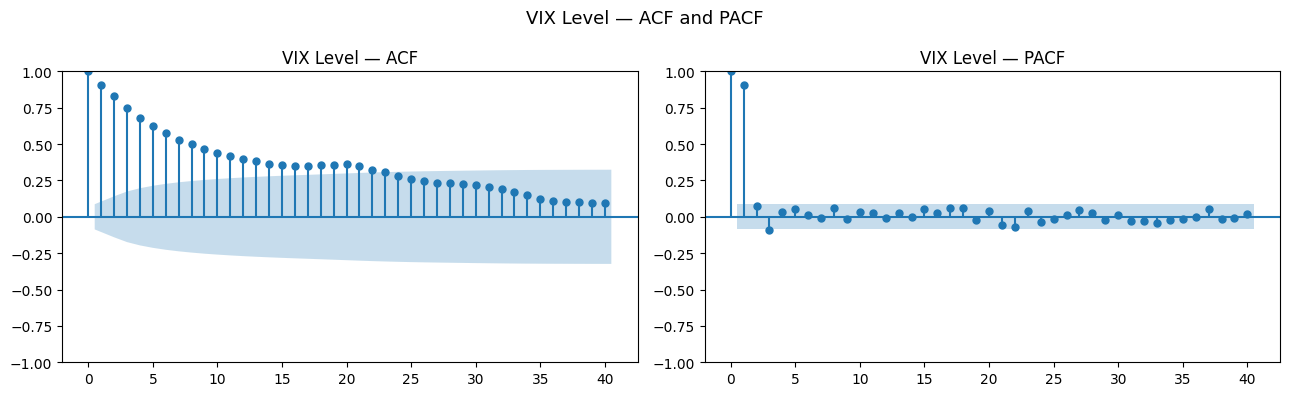

In [16]:
# Levels ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("VIX Level — ACF and PACF", fontsize=13)
plot_acf( data["vix"].dropna(), lags=40, ax=axes[0], title="VIX Level — ACF")
plot_pacf(data["vix"].dropna(), lags=40, ax=axes[1], title="VIX Level — PACF",
          method="ywm")
plt.tight_layout()
plt.savefig("fig3_vix_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Unit-root tests
def run_adf(series, name):
    res = adfuller(series.dropna(), autolag="AIC")
    return {"Series": name, "Test": "ADF",
            "Statistic": round(res[0], 3),
            "p-value": round(res[1], 4),
            "Lags": res[2],
            "H0": "Unit root",
            "Reject H0": "Yes" if res[1] < 0.05 else "No",
            "Conclusion": "Stationary" if res[1] < 0.05 else "Non-stationary"}

def run_kpss(series, name, regression="c"):
    stat, pval, lags, _ = kpss(series.dropna(), regression=regression, nlags="auto")
    # p-values are bounded at [0.01, 0.10]
    pval_str = f"≤{pval:.4f}" if pval in [0.01, 0.10] else f"{pval:.4f}"
    return {"Series": name, "Test": f"KPSS({regression})",
            "Statistic": round(stat, 3),
            "p-value": pval_str,
            "Lags": lags,
            "H0": "Stationary",
            "Reject H0": "Yes" if pval <= 0.05 else "No",
            "Conclusion": "Non-stationary" if pval <= 0.05 else "Stationary"}

In [18]:
series_specs = [
    (data["sp500"],"SP500 level", "ct"),
    (data["vix"], "VIX level", "c"),
    (data["sp500_ret"], "SP500 log returns", "c"),
    (data["log_vix_diff"], "log(VIX)_diff", "c"),
]

results = []
for series, name, kpss_reg in series_specs:
    results.append(run_adf(series, name))
    results.append(run_kpss(series, name, regression=kpss_reg))

results_df = pd.DataFrame(results)[[
    "Series", "Test", "Statistic", "p-value", "Lags", "H0", "Reject H0", "Conclusion"
]]

print("\n" + "="*95)
print("TABLE 1: UNIT ROOT TEST RESULTS")
print("="*95)
print(results_df.to_string(index=False))
print("\nNote: KPSS p-values reported as ≤0.01 or ≥0.10 indicate the statistic is outside")
print("the table bounds in statsmodels. The true p-value is more extreme than reported.")


TABLE 1: UNIT ROOT TEST RESULTS
           Series     Test  Statistic p-value  Lags         H0 Reject H0     Conclusion
      SP500 level      ADF     -0.894  0.7901     4  Unit root        No Non-stationary
      SP500 level KPSS(ct)      0.294 ≤0.0100    12 Stationary       Yes Non-stationary
        VIX level      ADF     -4.927     0.0     2  Unit root       Yes     Stationary
        VIX level  KPSS(c)      0.734  0.0105    12 Stationary       Yes Non-stationary
SP500 log returns      ADF    -13.277     0.0     3  Unit root       Yes     Stationary
SP500 log returns  KPSS(c)      0.059 ≤0.1000     7 Stationary        No     Stationary
    log(VIX)_diff      ADF    -23.548     0.0     0  Unit root       Yes     Stationary
    log(VIX)_diff  KPSS(c)      0.020 ≤0.1000     5 Stationary        No     Stationary

Note: KPSS p-values reported as ≤0.01 or ≥0.10 indicate the statistic is outside
the table bounds in statsmodels. The true p-value is more extreme than reported.


/tmp/ipykernel_786/1685152034.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, _ = kpss(series.dropna(), regression=regression, nlags="auto")
/tmp/ipykernel_786/1685152034.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, _ = kpss(series.dropna(), regression=regression, nlags="auto")
/tmp/ipykernel_786/1685152034.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, _ = kpss(series.dropna(), regression=regression, nlags="auto")


In [19]:
# VIX subsample test
print("\n" + "="*60)
print("VIX SUB-SAMPLE ANALYSIS (split: 2025-03-01)")
print("="*60)

split = "2025-03-01"
for label, subseries in [
    ("Pre-Mar 2025",  data.loc[:split,  "vix"]),
    ("Post-Mar 2025", data.loc[split:,  "vix"]),
]:
    adf_r = adfuller(subseries.dropna(), autolag="AIC")
    k_stat, k_pval, k_lags, _ = kpss(subseries.dropna(), regression="c", nlags="auto")
    print(f"\n{label}  (n={len(subseries.dropna())}):")
    print(f"  Mean: {subseries.mean():.2f},  Std: {subseries.std():.2f}")
    print(f"  ADF:  stat={adf_r[0]:.4f},  p={adf_r[1]:.4f}  "
          f" {'Reject unit root' if adf_r[1]<0.05 else 'Fail to reject'}")
    print(f"  KPSS: stat={k_stat:.4f},  p={k_pval:.4f}  "
          f" {'Reject stationarity' if k_pval<=0.05 else 'Fail to reject'}")



VIX SUB-SAMPLE ANALYSIS (split: 2025-03-01)

Pre-Mar 2025  (n=290):
  Mean: 15.79,  Std: 3.22
  ADF:  stat=-4.7964,  p=0.0001   Reject unit root
  KPSS: stat=0.8974,  p=0.0100   Reject stationarity

Post-Mar 2025  (n=221):
  Mean: 19.16,  Std: 5.60
  ADF:  stat=-3.2480,  p=0.0174   Reject unit root
  KPSS: stat=0.9276,  p=0.0100   Reject stationarity


/tmp/ipykernel_786/2780066588.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k_stat, k_pval, k_lags, _ = kpss(subseries.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_786/2780066588.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k_stat, k_pval, k_lags, _ = kpss(subseries.dropna(), regression="c", nlags="auto")


In [54]:
# Structural break
split = "2025-03-01"
pre  = data.loc[:split, "vix"].dropna()
post = data.loc[split:, "vix"].dropna()

# Chow test for structural break in VIX at March 2025
split = "2025-03-01"

vix_series = data["vix"].dropna().reset_index()
vix_series.columns = ["date", "vix"]
vix_series["t"] = np.arange(len(vix_series))  # time trend as regressor

# Split into pre and post
pre  = vix_series[vix_series["date"] < split]
post = vix_series[vix_series["date"] >= split]
full = vix_series.copy()

# OLS on each subsample and full sample
def fit_ols(df):
    X = sm.add_constant(df["t"])
    return sm.OLS(df["vix"], X).fit()

m_full = fit_ols(full)
m_pre  = fit_ols(pre)
m_post = fit_ols(post)

# Chow F-statistic
RSS_full = m_full.ssr
RSS_pre  = m_pre.ssr
RSS_post = m_post.ssr

k = 2        # number of parameters (const + trend)
n = len(full)
n1 = len(pre)
n2 = len(post)

F = ((RSS_full - (RSS_pre + RSS_post)) / k) / ((RSS_pre + RSS_post) / (n - 2*k))
p_value = 1 - stats.f.cdf(F, dfn=k, dfd=n - 2*k)

print(f"Chow Test for structural break at {split}")
print(f"{'='*45}")
print(f"RSS (full model):      {RSS_full:.6f}")
print(f"RSS (pre + post):      {RSS_pre + RSS_post:.6f}")
print(f"F-statistic:           {F:.4f}")
print(f"p-value:               {p_value:.6f}")
print(f"n={n}, n1={n1}, n2={n2}, k={k}")
print(f"\nConclusion: {'Reject' if p_value < 0.05 else 'Fail to reject'} null of no structural break at 5% level")

Chow Test for structural break at 2025-03-01
RSS (full model):      10447.576322
RSS (pre + post):      7492.192230
F-statistic:           99.9961
p-value:               0.000000
n=511, n1=290, n2=221, k=2

Conclusion: Reject null of no structural break at 5% level


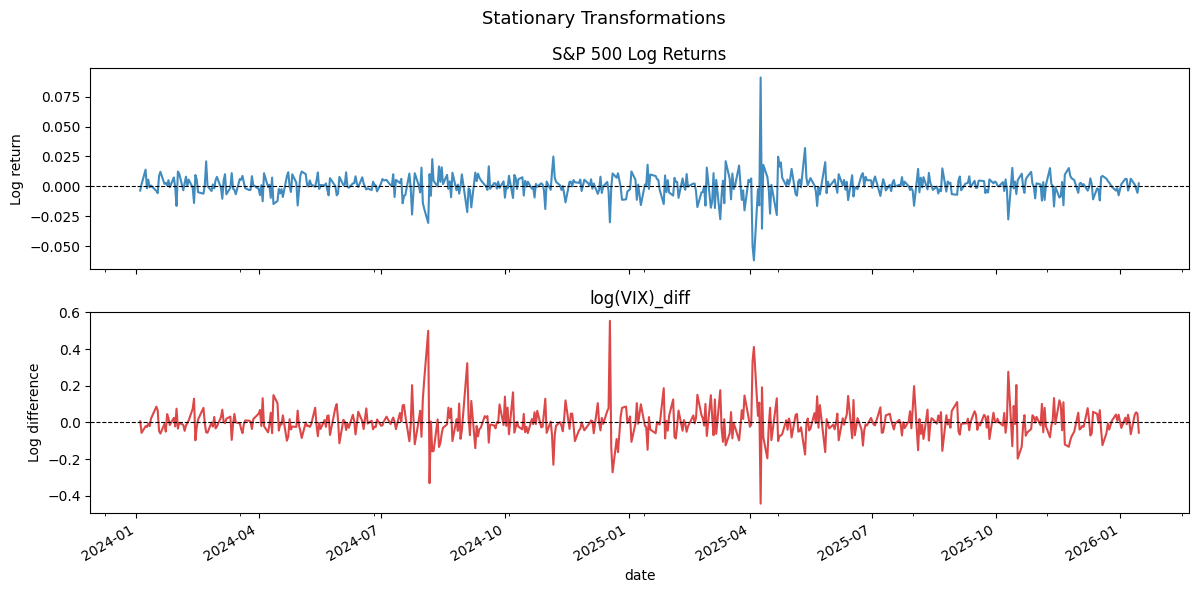

In [20]:
# Stationary series plots
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Stationary Transformations", fontsize=13)

data["sp500_ret"].dropna().plot(ax=axes[0], color="#1f77b4", alpha=0.85)
axes[0].set_title("S&P 500 Log Returns")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_ylabel("Log return")

data["log_vix_diff"].dropna().plot(ax=axes[1], color="#d62728", alpha=0.85)
axes[1].set_title("log(VIX)_diff")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("Log difference")

plt.tight_layout()
plt.savefig("fig4_stationary.png", dpi=150, bbox_inches="tight")
plt.show()

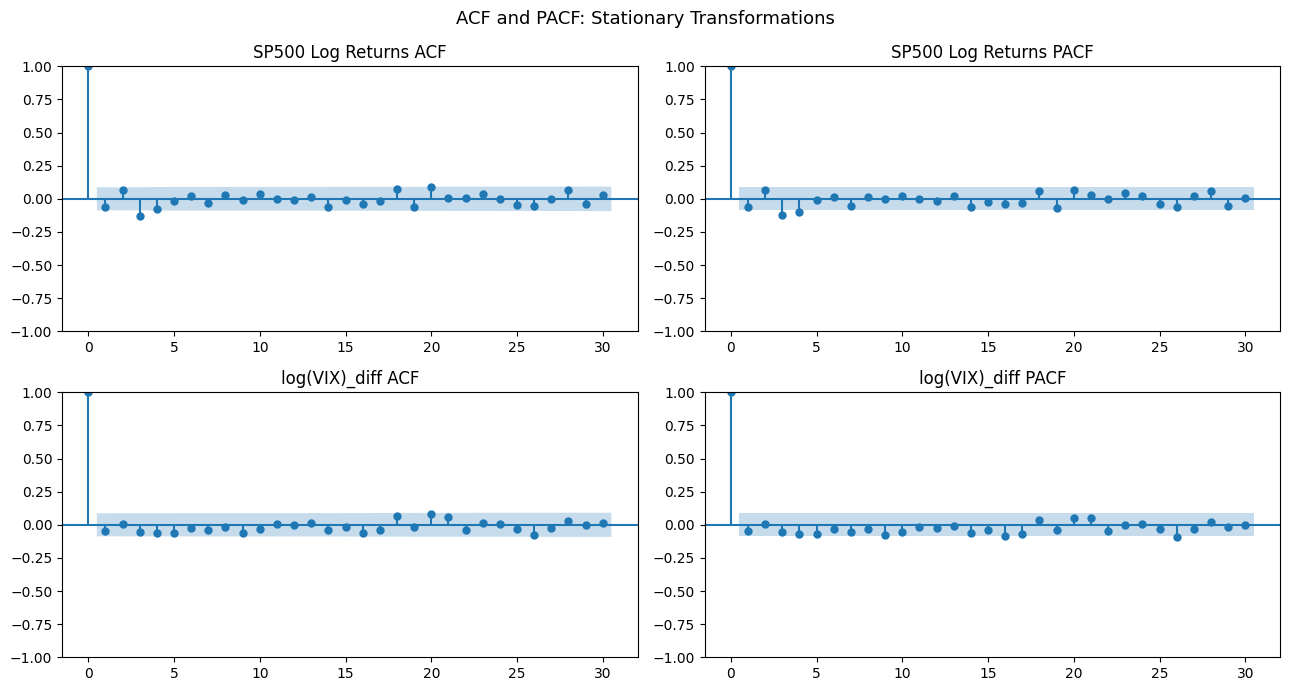

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("ACF and PACF: Stationary Transformations", fontsize=13)

plot_acf( data["sp500_ret"].dropna(),    lags=30, ax=axes[0,0],
          title="SP500 Log Returns ACF")
plot_pacf(data["sp500_ret"].dropna(),    lags=30, ax=axes[0,1],
          title="SP500 Log Returns PACF", method="ywm")
plot_acf( data["log_vix_diff"].dropna(), lags=30, ax=axes[1,0],
          title="log(VIX)_diff ACF")
plot_pacf(data["log_vix_diff"].dropna(), lags=30, ax=axes[1,1],
          title="log(VIX)_diff PACF", method="ywm")

plt.tight_layout()
plt.savefig("fig5_acf_pacf_stationary.png", dpi=150, bbox_inches="tight")
plt.show()

### ARMA

In [36]:
y_arma = data["sp500_ret"].dropna()

In [37]:
# Chosing ARMA(p,q)
results_grid = []
for p, q in itertools.product(range(11), range(11)):
    try:
        model = ARIMA(y_arma, order=(p, 0, q)).fit(method_kwargs={"warn_convergence": False})
        results_grid.append({
            "p": p, "q": q,
            "AIC": round(model.aic, 2),
            "BIC": round(model.bic, 2),
            "converged": True
        })
    except Exception:
        results_grid.append({"p": p, "q": q, "AIC": np.nan, "BIC": np.nan, "converged": False})

grid_df = pd.DataFrame(results_grid)

# Best models by each criterion
best_aic = grid_df.loc[grid_df["AIC"].idxmin()]
best_bic = grid_df.loc[grid_df["BIC"].idxmin()]

print(f"\nBest by AIC: ARMA({int(best_aic.p)},{int(best_aic.q)}) AIC={best_aic.AIC}")
print(f"Best by BIC: ARMA({int(best_bic.p)},{int(best_bic.q)}) BIC={best_bic.BIC}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Best by AIC: ARMA(0,4) AIC=-3261.13
Best by BIC: ARMA(0,0) BIC=-3243.67


In [25]:
# Robustness: ARMA grid for sp500_diff vs sp500_ret
y_diff = data["sp500_diff"].dropna()
y_ret  = data["sp500_ret"].dropna()

results_diff = []
for p, q in itertools.product(range(11), range(11)):
    try:
        model = ARIMA(y_diff, order=(p, 0, q)).fit(
            method_kwargs={"warn_convergence": False},
            cov_type="none", low_memory=True
        )
        results_diff.append({"p": p, "q": q,
                             "AIC": round(model.aic, 2),
                             "BIC": round(model.bic, 2)})
    except Exception:
        results_diff.append({"p": p, "q": q,
                             "AIC": np.nan, "BIC": np.nan})

grid_diff = pd.DataFrame(results_diff)
best_aic_diff = grid_diff.loc[grid_diff["AIC"].idxmin()]
best_bic_diff = grid_diff.loc[grid_diff["BIC"].idxmin()]

print("sp500_diff:")
print(f"  Best AIC: ARMA({int(best_aic_diff.p)},{int(best_aic_diff.q)})  "
      f"AIC={best_aic_diff.AIC}")
print(f"  Best BIC: ARMA({int(best_bic_diff.p)},{int(best_bic_diff.q)})  "
      f"BIC={best_bic_diff.BIC}")

print("\nsp500_ret (log returns) — already computed:")
print(f"  Best AIC: ARMA(0,4)  AIC=-3261.13")
print(f"  Best BIC: ARMA(0,0)  BIC=-3243.67")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


sp500_diff:
  Best AIC: ARMA(3,5)  AIC=5544.57
  Best BIC: ARMA(0,0)  BIC=5562.07

sp500_ret (log returns) — already computed:
  Best AIC: ARMA(0,4)  AIC=-3261.13
  Best BIC: ARMA(0,0)  BIC=-3243.67


In [27]:
# Top-10 models
print("\nTop 10 models by AIC:")
print(grid_df.nsmallest(10, "AIC")[["p","q","AIC","BIC"]].to_string(index=False))

print("\nTop 10 models by BIC:")
print(grid_df.nsmallest(10, "BIC")[["p","q","AIC","BIC"]].to_string(index=False))


Top 10 models by AIC:
 p  q      AIC      BIC
 0  4 -3261.13 -3235.72
 4  0 -3260.37 -3234.96
 1  3 -3260.28 -3234.87
 0  5 -3259.14 -3229.49
 2  3 -3258.98 -3229.34
 1  4 -3258.96 -3229.32
 0  3 -3258.89 -3237.72
 5  0 -3258.43 -3228.79
 4  1 -3258.39 -3228.75
 3  0 -3257.40 -3236.23

Top 10 models by BIC:
 p  q      AIC      BIC
 0  0 -3252.14 -3243.67
 1  0 -3252.06 -3239.36
 0  1 -3251.85 -3239.14
 0  3 -3258.89 -3237.72
 3  0 -3257.40 -3236.23
 0  4 -3261.13 -3235.72
 2  0 -3252.07 -3235.13
 4  0 -3260.37 -3234.96
 1  3 -3260.28 -3234.87
 0  2 -3251.40 -3234.46


In [49]:
# Estim ARMA(0,0) model (choice based on grid results and parsimony principle)
p_sel = int(best_bic.p)
q_sel = int(best_bic.q)

print(f"\n{'='*60}")
print(f"Preferred model: ARMA({p_sel},{q_sel})")
print(f"{'='*60}")

preferred = ARIMA(y_arma, order=(p_sel, 0, q_sel)).fit()
print(preferred.summary())


Preferred model: ARMA(0,0)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              sp500_ret   No. Observations:                  510
Model:                          ARIMA   Log Likelihood                1628.068
Date:                Wed, 04 Mar 2026   AIC                          -3252.136
Time:                        18:06:55   BIC                          -3243.667
Sample:                             0   HQIC                         -3248.815
                                - 510                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      1.713      0.087      -0.000       0.002
sigma2       9.89e-05   2.02e-06     49.072      0.000    9.49e-05       0.000
Ljung-Box (L1) (Q):                   1.93   Jarque-

In [50]:
# CHeck whether residuals in ARMA(0,0) are trully WN
m00 = ARIMA(y_arma, order=(0, 0, 0)).fit()
m04 = ARIMA(y_arma, order=(0, 0, 4)).fit()

resid00 = m00.resid.dropna()
resid04 = m04.resid.dropna()

# Ljung–Box
lb00_10 = acorr_ljungbox(resid00, lags=[10], return_df=True)
lb04_10 = acorr_ljungbox(resid04, lags=[10], return_df=True)

# ARCH + JB
arch00_stat, arch00_p, _, _ = het_arch(resid00, nlags=10)
arch04_stat, arch04_p, _, _ = het_arch(resid04, nlags=10)

jb00_stat, jb00_p, jb00_skew, jb00_kurt = jarque_bera(resid00)
jb04_stat, jb04_p, jb04_skew, jb04_kurt = jarque_bera(resid04)

# Comparison table (for report)
comparison = pd.DataFrame({
    "Metric": [
        "Log-Likelihood", "AIC", "BIC",
        "Ljung–Box p-val (lag 10)",
        "ARCH LM p-val (lags=10)",
        "JB p-val (normality)"
    ],
    "ARMA(0,0)": [
        m00.llf, m00.aic, m00.bic,
        float(lb00_10["lb_pvalue"].iloc[0]),
        arch00_p,
        jb00_p
    ],
    "ARMA(0,4)": [
        m04.llf, m04.aic, m04.bic,
        float(lb04_10["lb_pvalue"].iloc[0]),
        arch04_p,
        jb04_p
    ]
})

comparison["ARMA(0,0)"] = comparison["ARMA(0,0)"].map(lambda x: f"{x:.6f}")
comparison["ARMA(0,4)"] = comparison["ARMA(0,4)"].map(lambda x: f"{x:.6f}")

print(comparison.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                  Metric    ARMA(0,0)    ARMA(0,4)
          Log-Likelihood  1628.067766  1636.565020
                     AIC -3252.135533 -3261.130040
                     BIC -3243.666711 -3235.723576
Ljung–Box p-val (lag 10)     0.059184     0.999428
 ARCH LM p-val (lags=10)     0.000000     0.000000
    JB p-val (normality)     0.000000     0.000000


### Distributed lag model

In [55]:
# Setting
y = data["sp500_ret"].dropna() # log returns
x = data["vix_diff"].dropna() # decided on differened VIX since VIX appears to be not covariance stationary
# (structural break, non-constant mean, KPSS rejects stationarity even though ADF rejects unit root)

# Align series
df = pd.DataFrame({"y": y, "x": x}).dropna()

In [48]:
# Lag seletion
# df contains columns: y, x
max_k = 10
lag_results = []

for k in range(max_k + 1):
    X = pd.concat(
        [df["x"].shift(lag).rename(f"x_lag{lag}") for lag in range(k + 1)],
        axis=1
    )
    X = sm.add_constant(X)

    reg = pd.concat([df["y"], X], axis=1).dropna()
    y_aligned = reg["y"]
    X_aligned = reg.drop(columns=["y"])

    model = sm.OLS(y_aligned, X_aligned).fit()

    lag_results.append({
        "k": k,
        "AIC": model.aic,
        "BIC": model.bic,
        "R2": model.rsquared
    })

lag_df = pd.DataFrame(lag_results)
print(lag_df.round({"AIC":2, "BIC":2, "R2":4}).to_string(index=False))

best_k_aic = int(lag_df.loc[lag_df["AIC"].idxmin(), "k"])
best_k_bic = int(lag_df.loc[lag_df["BIC"].idxmin(), "k"])

print(f"\nBest k by AIC: {best_k_aic}")
print(f"Best k by BIC: {best_k_bic}")

 k      AIC      BIC     R2
 0 -3876.41 -3867.95 0.7060
 1 -3866.59 -3853.90 0.7063
 2 -3863.69 -3846.77 0.7107
 3 -3861.71 -3840.57 0.7146
 4 -3851.63 -3826.27 0.7149
 5 -3842.76 -3813.18 0.7158
 6 -3836.22 -3802.44 0.7181
 7 -3826.95 -3788.96 0.7188
 8 -3818.84 -3776.66 0.7201
 9 -3812.59 -3766.21 0.7224
10 -3805.99 -3755.41 0.7242

Best k by AIC: 0
Best k by BIC: 0


In [53]:
# Create lags x_lag0 to x_lag10 of VIX level
Kmax = 10
for k in range(Kmax + 1):
    df[f"x_lag{k}"] = df["x"].shift(k)

# Drop NAs created by lagging and store in reg_df
reg_df = df.dropna(subset=["y"] + [f"x_lag{k}" for k in range(Kmax + 1)]).copy()

# Estimate full K=10 distributed lag model with HAC standard errors
Y = reg_df["y"]
X = sm.add_constant(reg_df[[f"x_lag{k}" for k in range(Kmax + 1)]])
dl_full = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
print(dl_full.summary())

# Wald test: lags 6-10 jointly zero in full model
hyp = "x_lag6 = x_lag7 = x_lag8 = x_lag9 = x_lag10 = 0"
print(dl_full.wald_test(hyp))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     37.48
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           4.33e-58
Time:                        18:29:28   Log-Likelihood:                 1915.0
No. Observations:                 500   AIC:                            -3806.
Df Residuals:                     488   BIC:                            -3755.
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      4.043      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


Intrepretation: 0 lag model

y_t​=α+β0_​Δx_t​+ε_t​
where
- y_t​=ln(SP500_t​)−ln(SP500_(t−1)​) — S&P 500 log return
- Δx_t​=VIX_t​−VIX_(t−1)​ — first difference of VIX
- ε_t​ — error term
- t = 1,…,T

In [64]:
# Estimate chosen model
df_final = df.copy().dropna()
y_final = df_final["y"]
X_final = sm.add_constant(df_final["x"])

final_model = sm.OLS(y_final, X_final).fit()
residuals = final_model.resid

# Test for autocorrelation in residuals
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

# Test for heteroskedasticity
arch_stat, arch_p, _, _ = het_arch(residuals, nlags=10)
print(f"ARCH LM p-value: {arch_p:.4f}")

# Then estimate final models with robust SEs
model_hc3 = sm.OLS(y_final, X_final).fit(cov_type="HC3")
model_hac  = sm.OLS(y_final, X_final).fit(cov_type="HAC",
                                           cov_kwds={"maxlags": 4})
print(model_hc3.params)  # verify column names

      lb_stat  lb_pvalue
10  15.698227   0.108603
ARCH LM p-value: 0.0000
const    0.000778
x       -0.004072
dtype: float64


Intrepretation: only heteroskedasticity is present

In [65]:
# Estimate with White SEs
model_hc3 = sm.OLS(y, x).fit(cov_type="HC3")
print("="*60)
print("Model with White Standard Errors")
print("="*60)
print(model_hc3.summary())

# Estimate with HAC (Newey-West) SEs
model_hac = sm.OLS(y, x).fit(cov_type="HAC",
                                          cov_kwds={"maxlags": 4})
print("="*60)
print("Model with HAC (Newey-West) Standard Errors, maxlags=4")
print("="*60)
print(model_hac.summary())

Model with White Standard Errors
                                 OLS Regression Results                                
Dep. Variable:              sp500_ret   R-squared (uncentered):                   0.702
Model:                            OLS   Adj. R-squared (uncentered):              0.701
Method:                 Least Squares   F-statistic:                              112.5
Date:                Wed, 04 Mar 2026   Prob (F-statistic):                    7.03e-24
Time:                        20:37:58   Log-Likelihood:                          1935.0
No. Observations:                 510   AIC:                                     -3868.
Df Residuals:                     509   BIC:                                     -3864.
Df Model:                           1                                                  
Covariance Type:                  HC3                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
--------

In [68]:
# Comparison table of key results
comparison = pd.DataFrame({
    "": ["Coefficient", "Std Error", "t-stat", "p-value"],
    "HC3 (White)": [
        model_hc3.params["vix_diff"],
        model_hc3.bse["vix_diff"],
        model_hc3.tvalues["vix_diff"],
        model_hc3.pvalues["vix_diff"]
    ],
    "HAC (NW, 4 lags)": [
        model_hac.params["vix_diff"],
        model_hac.bse["vix_diff"],
        model_hac.tvalues["vix_diff"],
        model_hac.pvalues["vix_diff"]
    ]
})

print("\nRobustness comparison for β₀ (vix_diff):")
print(comparison.round(6).to_string(index=False))


Robustness comparison for β₀ (vix_diff):
             HC3 (White)  HAC (NW, 4 lags)
Coefficient    -0.004072         -0.004072
  Std Error     0.000384          0.000432
     t-stat   -10.605973         -9.429139
    p-value     0.000000          0.000000


Intrepretation: result is robust to the choice of SEs. HAC yields an identical point estimate with only marginally larger SEs, confirming the inference is not sensitive to autocorrelation correction.

### Relationship between volatility & equity returns: structural break

Identified breakpoint: 2024-12-23
Maximum F-statistic:   26.9274


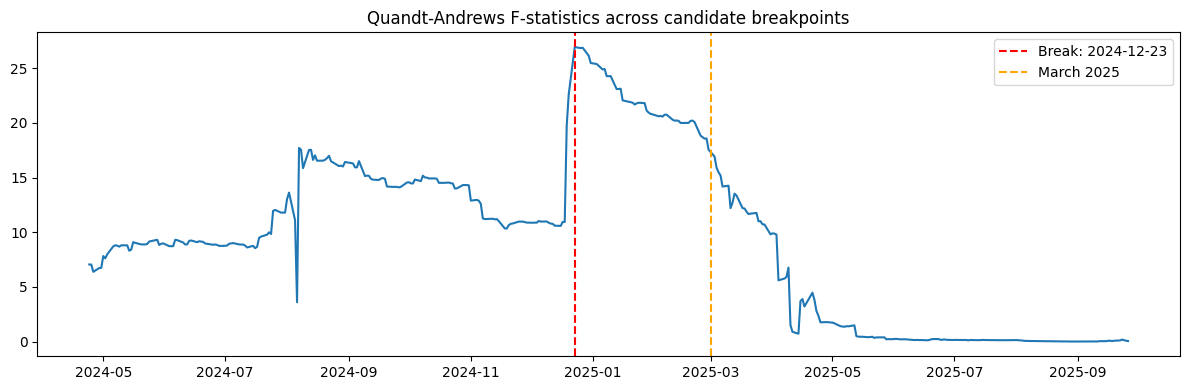

In [71]:
# Quandt-Andrews unknown breakpoint test (structural break in regression relationship)
y_ = df_final["y"].values
X_ = sm.add_constant(df_final["x"].values)

n = len(df_final)
trim = int(0.15 * n)
dates = df_final.index

F_stats = []
for i in range(trim, n - trim):
    m_pre  = sm.OLS(y_[:i],  X_[:i]).fit()
    m_post = sm.OLS(y_[i:],  X_[i:]).fit()
    m_full = sm.OLS(y_,      X_).fit()

    k = 2
    F = ((m_full.ssr - (m_pre.ssr + m_post.ssr)) / k) / \
        ((m_pre.ssr + m_post.ssr) / (n - 2*k))
    F_stats.append((dates[i], F))

F_df = pd.DataFrame(F_stats, columns=["date", "F_stat"])
best = F_df.loc[F_df["F_stat"].idxmax()]

print(f"Identified breakpoint: {best['date'].date()}")
print(f"Maximum F-statistic:   {best['F_stat']:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(F_df["date"], F_df["F_stat"], color="#1f77b4")
plt.axvline(best["date"], color="red", ls="--", label=f"Break: {best['date'].date()}")
plt.axvline(pd.Timestamp("2025-03-01"), color="orange", ls="--", label="March 2025")
plt.title("Quandt-Andrews F-statistics across candidate breakpoints")
plt.legend()
plt.tight_layout()
plt.savefig("fig_quandt_andrews.png", dpi=150, bbox_inches="tight")
plt.show()

In [73]:
# Chow test at 2024-12-23
split_qa = "2024-12-23"

df_pre  = df_final[df_final.index < split_qa]
df_post = df_final[df_final.index >= split_qa]

# Estimate models
def fit_ols_sub(df_sub):
    y_ = df_sub["y"]
    X_ = sm.add_constant(df_sub["x"])
    return sm.OLS(y_, X_).fit()

m_full = fit_ols_sub(df_final)
m_pre  = fit_ols_sub(df_pre)
m_post = fit_ols_sub(df_post)

# Chow F-statistic
k  = 2
n  = len(df_final)
n1 = len(df_pre)
n2 = len(df_post)

F = ((m_full.ssr - (m_pre.ssr + m_post.ssr)) / k) / \
    ((m_pre.ssr + m_post.ssr) / (n - 2*k))
p_value = 1 - stats.f.cdf(F, dfn=k, dfd=n - 2*k)

print(f"Chow Test at Quandt-Andrews breakpoint ({split_qa})")
print(f"{'='*50}")
print(f"F-statistic:    {F:.4f}")
print(f"p-value:        {p_value:.6f}")
print(f"n={n}, n1={n1}, n2={n2}, k={k}")
print(f"\nPre-break β0: {m_pre.params['x']:.6f}  (n={n1})")
print(f"Post-break β0: {m_post.params['x']:.6f}  (n={n2})")
print(f"Full sample β0: {m_full.params['x']:.6f}")
print(f"\nConclusion: {'Reject' if p_value < 0.05 else 'Fail to reject'} null of parameter stability at 5% level")

Chow Test at Quandt-Andrews breakpoint (2024-12-23)
F-statistic:    26.9274
p-value:        0.000000
n=510, n1=244, n2=266, k=2

Pre-break β0: -0.003065  (n=244)
Post-break β0: -0.004720  (n=266)
Full sample β0: -0.004072

Conclusion: Reject null of parameter stability at 5% level


Intrepretation: yes, the relationship between volatility and equity returns changed over the sample period, with statistically and economically significant evidence of a break in December 2024.

In [77]:
y_final = df_final["y"]
X_final = sm.add_constant(df_final["x"])

# Verify
print(X_final.columns.tolist())  # should show ['const', 'x']

# Re-estimate
model_hc3 = sm.OLS(y_final, X_final).fit(cov_type="HC3")
model_hac  = sm.OLS(y_final, X_final).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print(model_hc3.summary())

['const', 'x']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     115.0
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.54e-24
Time:                        20:56:09   Log-Likelihood:                 1940.2
No. Observations:                 510   AIC:                            -3876.
Df Residuals:                     508   BIC:                            -3868.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000     

In [78]:
# Subsample models with WHite SEs
m_pre_hc3  = sm.OLS(df_pre["y"],  sm.add_constant(df_pre["x"])).fit(cov_type="HC3")
m_post_hc3 = sm.OLS(df_post["y"], sm.add_constant(df_post["x"])).fit(cov_type="HC3")

print("\nPre-break model:")
print(m_pre_hc3.summary())

print("\nPost-break model:")
print(m_post_hc3.summary())


Pre-break model:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     30.14
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.02e-07
Time:                        20:56:37   Log-Likelihood:                 920.81
No. Observations:                 244   AIC:                            -1838.
Df Residuals:                     242   BIC:                            -1831.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000  